In [1]:
!pip install numpy matplotlib scikit-learn pytest joblib -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import joblib

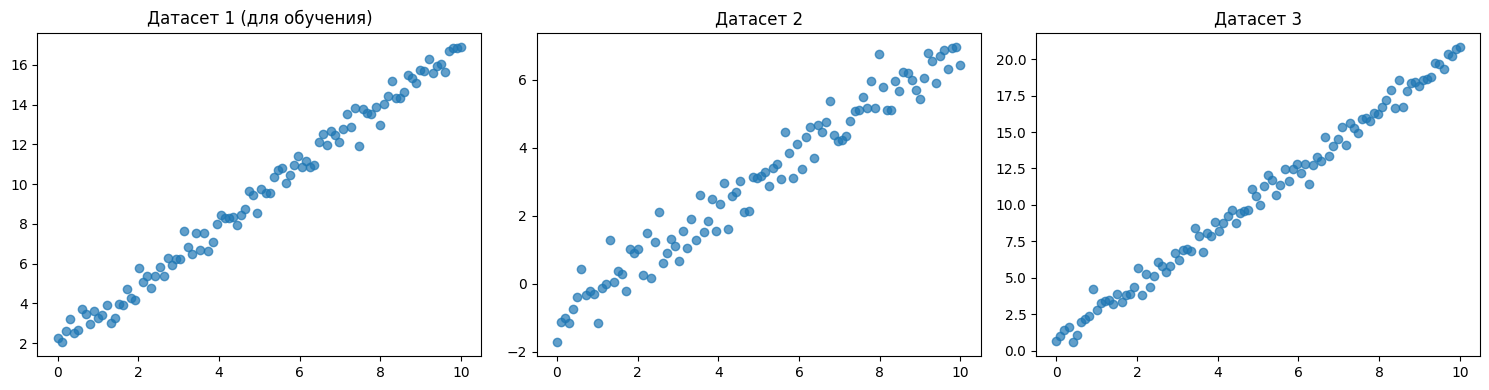

In [4]:
np.random.seed(42)
n_points = 100
x = np.linspace(0, 10, n_points)

y1 = 1.5 * x + 2 + np.random.normal(0, 0.5, n_points)

y2 = 0.8 * x - 1 + np.random.normal(0, 0.5, n_points)

y3 = 2.0 * x + 0.5 + np.random.normal(0, 0.5, n_points)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(x, y1, alpha=0.7)
axes[0].set_title('Датасет 1 (для обучения)')
axes[1].scatter(x, y2, alpha=0.7)
axes[1].set_title('Датасет 2')
axes[2].scatter(x, y3, alpha=0.7)
axes[2].set_title('Датасет 3')
plt.tight_layout()
plt.show()

In [5]:
X = x.reshape(-1, 1)
model = LinearRegression()
model.fit(X, y1)

print(f"Коэффициент наклона: {model.coef_[0]:.3f}")
print(f"Интерцепт: {model.intercept_:.3f}")
print(f"R^2 на обучающем датасете: {model.score(X, y1):.3f}")

Коэффициент наклона: 1.507
Интерцепт: 1.914
R^2 на обучающем датасете: 0.990


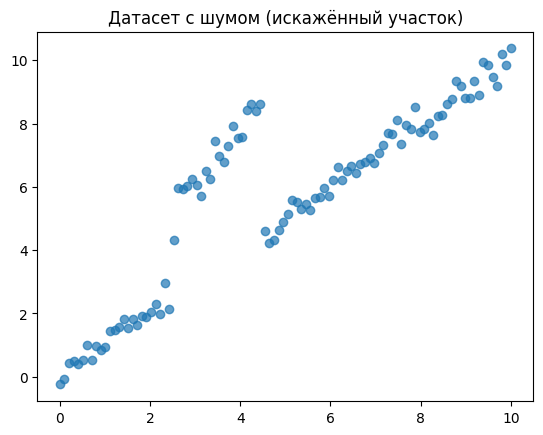

In [6]:
y_noisy = x + np.random.normal(0, 0.3, n_points)
y_noisy[25:45] *= 2

plt.scatter(x, y_noisy, alpha=0.7)
plt.title("Датасет с шумом (искажённый участок)")
plt.show()

In [7]:
joblib.dump(model, 'model.pkl')
np.savez('datasets.npz', x=x, y_train=y1, y_noisy=y_noisy)

In [8]:
%%writefile test_regression.py
import numpy as np
import joblib
from sklearn.metrics import mean_squared_error

def load_data():
    model = joblib.load('model.pkl')
    data = np.load('datasets.npz')
    return model, data['x'], data['y_train'], data['y_noisy']

def test_training_data():
    model, x, y_train, _ = load_data()
    X = x.reshape(-1, 1)
    y_pred = model.predict(X)
    mse = mean_squared_error(y_train, y_pred)
    # На обучающем датасете ошибка должна быть маленькой
    assert mse < 1.0, f"Ошибка на обучающем датасете слишком велика: {mse:.3f}"

def test_noisy_data():
    model, x, _, y_noisy = load_data()
    X = x.reshape(-1, 1)
    y_pred = model.predict(X)
    mse = mean_squared_error(y_noisy, y_pred)
    # Ожидаем, что на зашумлённых данных MSE будет > 5.0 (проблема)
    # Если MSE окажется меньше порога, тест пройдёт – но в нашем случае он упадёт.
    assert mse < 5.0, f"ПРОБЛЕМА ОБНАРУЖЕНА: MSE на шумном датасете = {mse:.3f} (выше допустимого 5.0)"

Writing test_regression.py


In [9]:
!pytest test_regression.py -v

============================= test session starts =============================
platform win32 -- Python 3.14.0, pytest-9.0.1, pluggy-1.6.0 -- C:\Users\МашкинМихаилЕвгеньев\AppData\Local\Programs\Python\Python314\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\МашкинМихаилЕвгеньев\PycharmProjects\mlops_practice
plugins: anyio-4.11.0, hydra-core-1.3.2
collecting ... collected 2 items

test_regression.py::test_training_data PASSED                            [ 50%]
test_regression.py::test_noisy_data FAILED                               [100%]

================================== FAILURES ===================================
_______________________________ test_noisy_data _______________________________

    def test_noisy_data():
        model, x, _, y_noisy = load_data()
        X = x.reshape(-1, 1)
        y_pred = model.predict(X)
        mse = mean_squared_error(y_noisy, y_pred)
        # Ожидаем, что на зашумлённых данных MSE будет > 5.0 (проблема)
        # Если MSE окажется мен

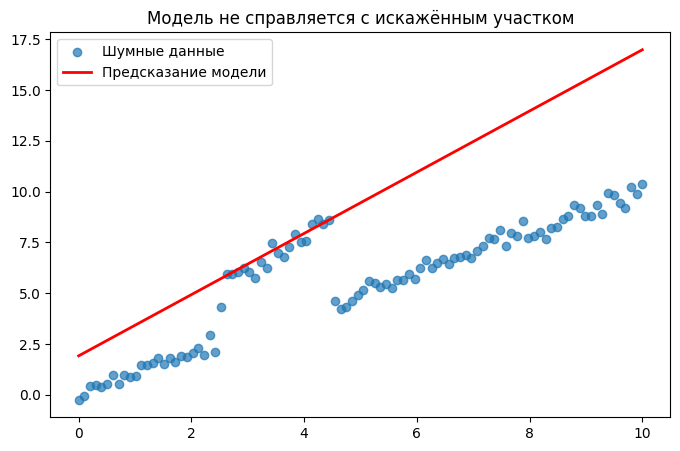

In [10]:
X_plot = x.reshape(-1, 1)
y_pred = model.predict(X_plot)

plt.figure(figsize=(8, 5))
plt.scatter(x, y_noisy, alpha=0.7, label='Шумные данные')
plt.plot(x, y_pred, 'r-', linewidth=2, label='Предсказание модели')
plt.title("Модель не справляется с искажённым участком")
plt.legend()
plt.show()